In [1]:
import pandas as pd
import pypowsybl.network as pn
import pypowsybl as pp
from pypowsybl_jupyter import nad_explorer
import re
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import builtins
import itertools
import importlib
import utils

from utils import edges_with_impedance, median,cluster_subgraph,network_construction, type_controller, unique_list, plot_slack_cluster, slack_subgraph_2nd, plot_graph, dfs_slack_2nd, slack_subgraph, has_slack, visualize_graph, dfs_with_slack, median 

In [3]:
importlib.reload(utils)

<module 'utils' from 'd:\\dev\\powsybl-open-loadflow-knitro-solver\\utils.py'>

In [4]:
network_name = "test_active_power_and_correction_all_load_5_ieee/ieee300"
network ="ieee300"
extension_in = '.xiidm'
network = pn.load('./Outputs/' + network +"-"+"active-perturbation" + extension_in)
edges = edges_with_impedance(network) 
G = nx.from_pandas_edgelist(edges,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
dist_weighted = dict(nx.shortest_path_length(G, weight="impedance_module"))
dist = dict(nx.shortest_path_length(G))

In [5]:
load_B = [x.strip() for x in """
B1-L,B2-L, B3-L, B5-L, B6-L, B8-L, B9-L, B10-L, B11-L, B13-L, B14-L, B15-L, B17-L, B20-L, B21-L, B22-L, B23-L, B25-L, B26-L, B27-L, B33-L, B37-L, B38-L, B40-L, B41-L, B43-L, B44-L, B47-L, B48-L, B49-L, B52-L, B53-L, B54-L, B55-L, B57-L, B58-L, B59-L, B61-L, B63-L, B70-L, B71-L, B72-L, B73-L, B76-L, B77-L, B79-L, B80-L, B84-L, B89-L, B90-L, B91-L, B92-L, B94-L, B97-L, B98-L, B99-L, B102-L, B103-L, B104-L, B105-L, B107-L, B108-L, B109-L, B110-L, B112-L, B113-L, B114-L, B121-L, B124-L, B118-L, B120-L, B122-L, B123-L, B125-L, B126-L, B127-L, B135-L, B136-L, B137-L, B138-L, B139-L, B140-L, B141-L, B142-L, B143-L, B148-L, B145-L, B152-L, B154-L, B155-L, B156-L, B157-L, B159-L, B161-L, B162-L, B167-L, B170-L, B171-L, B172-L, B173-L, B175-L, B176-L, B177-L, B178-L, B179-L, B180-L, B181-L, B182-L, B183-L, B184-L, B186-L, B187-L, B188-L, B189-L, B191-L, B192-L, B204-L, B196-L, B197-L, B198-L, B199-L, B200-L, B201-L, B202-L, B203-L, B206-L, B208-L, B209-L, B211-L, B214-L, B215-L, B216-L, B217-L, B218-L, B220-L, B221-L, B222-L, B223-L, B224-L, B225-L, B227-L, B228-L, B229-L, B231-L, B232-L, B233-L, B234-L, B235-L, B238-L, B243-L, B245-L, B246-L, B247-L, B248-L, B249-L, B319-L, B320-L, B322-L, B324-L, B526-L, B528-L, B531-L, B562-L, B609-L, B1190-L, B9003-L, B9004-L, B9021-L, B9022-L, B9024-L, B9025-L, B9026-L, B9031-L, B9032-L, B9033-L, B9034-L, B9035-L, B9037-L, B9038-L, B9036-L, B9041-L, B9042-L, B9043-L, B9052-L, B9071-L, B9072-L, B9121-L, B9533-L
""".split(",") if x.strip()]

In [6]:
len(load_B)

188

In [7]:
# # slack_info 
# network_name = "test_active_power_and_correction_more_ieee/ieee300/ieee300"
# network ="ieee300"
# pertubation = "active-perturbation"
# data = pd.read_csv(
#     network_name +"_" + pertubation + ".csv",
#     sep=";",
#     engine="python",
#     index_col=False,
#    # on_bad_lines="skip",
# )
# optim_info = pd.read_csv(
#     network_name + "_" + pertubation + "_optim_info.csv",
#     sep=";",
#     engine="python",
#     index_col=False,
# )
# extension_in = '.xiidm'
# network = pn.load('./Outputs/' + network +"-"+pertubation + extension_in)
# edges = edges_with_impedance(network)

# data_grouped = data.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
# data_grouped['Total_slack_abs'] = data_grouped['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
# G, dist, pos = network_construction(edges, data_grouped)
# clusters = slack_subgraph(G, data_grouped)
# data_grouped = cluster_subgraph(G, clusters, data_grouped, dist)
# fig = plot_slack_cluster(G, pos, clusters,data_grouped,data, col_centroid='centroid')
# fig.show()

In [8]:
optim_info = pd.read_csv( 
    network_name  +"_load0/ieee300_load0_active-perturbation"
   + "_optim_info.csv",
    sep=";",
    engine="python",
    index_col=False,
)
optim_info

,total_penalty,penaltyP,penaltyQ,penaltyV,status,iterations
0,1282.693158,1035.955223,192.409984,54.327951,-104,154


In [9]:
# slack_info 
load_id =0
pertubation = "_load"
distances_resume = pd.DataFrame(columns=["test number", "load_name", "source_node", "main_centroid", "distance_to_centroid", "total_penalty", "penaltyP", "penaltyQ", "penaltyV"])

for load_id in range(0,188):
    load_str = str(load_id)
    if load_id == 29:
        continue
        
    data = pd.read_csv(
    network_name  + pertubation +load_str+"/ieee300_load"+load_str+"_active-perturbation"+ ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
    optim_info = pd.read_csv( 
    network_name  + pertubation +load_str+"/ieee300_load"+load_str+"_active-perturbation"
   + "_optim_info.csv",
    sep=";",
    engine="python",
    index_col=False,
)

    data_grouped = data.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load']].agg(unique_list)
    data_grouped['Total_slack_abs'] = data_grouped['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
    G,dist_w, pos = network_construction(edges, data_grouped)
    clusters = slack_subgraph(G, data_grouped)
    data_grouped = cluster_subgraph(G, clusters, data_grouped, dist_w)

    load_name = load_B[load_id]
    source_node = network.get_loads().loc[load_name, "bus_id"]
    sum_p_abs_idx = pd.to_numeric(data_grouped['sum_P'], errors='coerce').abs().idxmax()
    main_centroid = data_grouped.loc[sum_p_abs_idx, 'centroid'] ## main centroid ? by size or total slack ? 
    
    # distance_w_uv = dist_weighted[source_node][main_centroid]
    distance_uv = dist[main_centroid][source_node]

    # distance = nx.shortest_path_length(G, source=source_node, target=main_centroid)
    # distance_weighted = nx.shortest_path_length(G, source=source_node, target=main_centroid, weight='impedance_module')
### regarder distance sans barycentre ? ou avec ?? 

    new_row = pd.DataFrame([{
        "test number": load_id,
        "load_name": load_name,
        "source_node": source_node,
        "main_centroid": main_centroid,
        "distance_to_centroid": distance_uv,
        # "distance_weighted_to_centroid": distance_w_uv,
        "total_penalty": optim_info.loc[0, "total_penalty"] if not optim_info.empty else np.nan,
        "penaltyP": optim_info.loc[0, "penaltyP"] if not optim_info.empty else np.nan,
        "penaltyQ": optim_info.loc[0, "penaltyQ"] if not optim_info.empty else np.nan,
        "penaltyV": optim_info.loc[0, "penaltyV"] if not optim_info.empty else np.nan,
        "status": optim_info.loc[0, "status"] if not optim_info.empty else np.nan, 
        "iterations": optim_info.loc[0, "iterations"] if not optim_info.empty else np.nan,
    }])

    distances_resume = pd.concat([distances_resume, new_row], ignore_index=True)

  

    #opti_resume = pd.DataFrame(summary_rows)
    # fig = plot_slack_cluster(G, pos, clusters,data_grouped,data, col_centroid='centroid')
    # fig.show()

Focal bus perturbation VL5_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan, nan], [nan], ['VL5_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL191_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL191_0', controllerElements=[VL191_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B191-G'], [nan], [nan], ['VL191_0_load'])
Focal bus perturbation VL191_0 has dominant slack V but no suitable controller
Focal bus perturbation VL7049_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7049_0', controllerElements=[VL7049_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B7049-G'], [nan], [nan], [nan])
Focal bus perturbation VL7049_0 has dominant slack V but no suitable controller
Focal bus p

In [10]:
distances_resume["status_name"] = np.select(
    [   distances_resume["status"].eq(0),
        distances_resume["status"].between(-199, -100, inclusive="both"),
        distances_resume["status"].eq(-410),
        distances_resume["status"].eq(-400),
    ],
    [   "CONVERGED_TO_LOCAL_OPTIMUM",
        "converged to feasible approximate solution",
        "Max iterations",
        "Max iterations",
    ],
    default="other"
)

In [11]:
distances_resume

,test number,load_name,source_node,main_centroid,distance_to_centroid,total_penalty,penaltyP,penaltyQ,penaltyV,status,iterations,status_name
0,0,B1-L,VL1_0,VL5_0,1,1282.693158,1035.955223,192.409984,54.327951,-104.0,154.0,converged to feasible approximate solution
1,1,B2-L,VL1_1,VL1_1,0,765.078655,676.953963,36.068362,52.05633,-104.0,100.0,converged to feasible approximate solution
2,2,B3-L,VL3_0,VL3_0,0,416.173377,393.894844,0.000005,22.278528,-104.0,108.0,converged to feasible approximate solution
3,3,B5-L,VL5_0,VL5_0,0,1177.617862,898.286078,225.08665,54.245133,-104.0,160.0,converged to feasible approximate solution
4,4,B6-L,VL5_1,VL5_1,0,1403.364525,1053.181684,291.51921,58.663631,-104.0,91.0,converged to feasible approximate solution
...,...,...,...,...,...,...,...,...,...,...,...,...
182,183,B9052-L,VL9051_1,VL9051_1,0,12972.420786,12843.756408,91.071441,37.592937,-104.0,47.0,converged to feasible approximate solution
183,184,B9071-L,VL9071_0,VL9071_0,0,14099.196577,14088.440535,10.163948,0.592095,-104.0,49.0,converged to feasible approximate solution
184,185,B9072-L,VL9071_1,VL9071_1,0,14036.248424,14022.316842,12.951972,0.97961,-104.0,59.0,converged to feasible approximate solution
185,186,B9121-L,VL9121_0,VL9121_0,0,13870.402592,13845.09757,21.98322,3.321802,-104.0,55.0,converged to feasible approximate solution


In [12]:
# sum_p_abs_idx = pd.to_numeric(data_grouped['sum_P'], errors='coerce').abs().idxmax()
# main_centroid = data_grouped.loc[sum_p_abs_idx, 'centroid']
# main_centroid

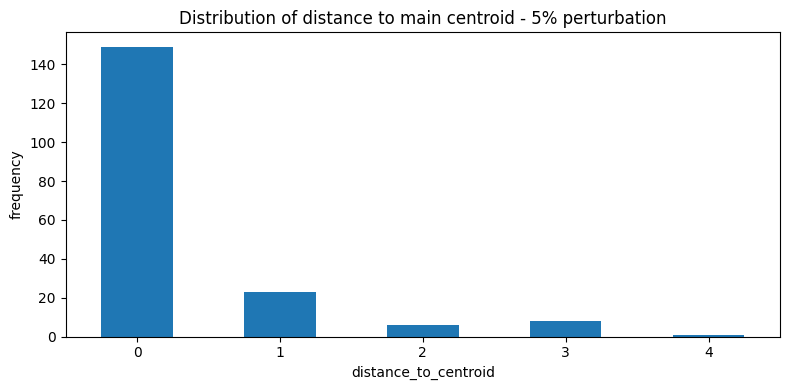

In [19]:
# Frequency of distance_to_centroid split by status
freq_status = (
    distances_resume
    .groupby(["distance_to_centroid"])
    .size()
  
    .sort_index()
)

ax = freq_status.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab10")
ax.set_xlabel("distance_to_centroid")
ax.set_ylabel("frequency")
ax.set_title("Distribution of distance to main centroid - 5% perturbation")
plt.xticks(rotation=0)
# custom_labels = {
#     "-410.0": "Max iteration reached",
#     "-104.0": "converged to feasible approximate solution",
#     "-400.0": "Max iterations"
# }

# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, [custom_labels.get(lbl, lbl) for lbl in labels], title="solver status")
plt.tight_layout()
plt.show()

In [20]:
distances_resume['distance_to_centroid'].value_counts()

distance_to_centroid
0    149
1     23
3      8
2      6
4      1
Name: count, dtype: int64

In [23]:
distances_resume.loc[distances_resume['distance_to_centroid'] == 12]

,test number,load_name,source_node,main_centroid,distance_to_centroid,total_penalty,penaltyP,penaltyQ,penaltyV,status,iterations,status_name
78,79,B138-L,VL138_0,VL7039_0,12,2.519871,0.000001,0.0,2.51987,0.0,18.0,CONVERGED_TO_LOCAL_OPTIMUM


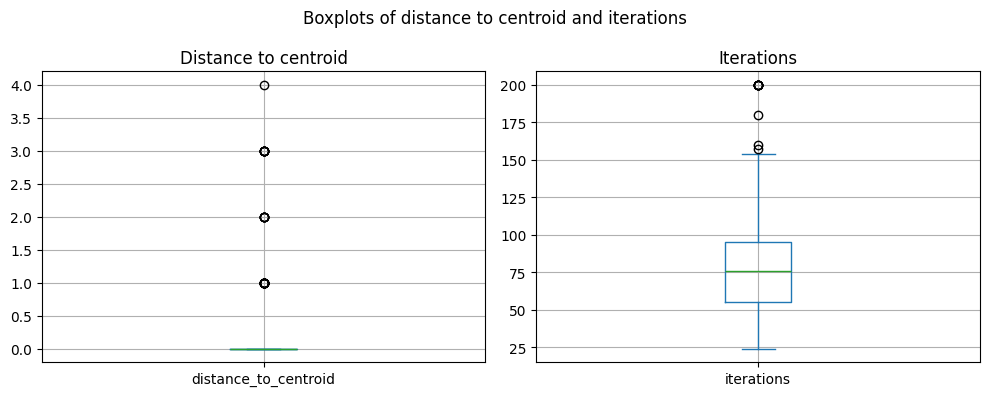

In [21]:
# Boxplots for iterations and distance_to_centroid
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

distances_resume["distance_to_centroid"].plot(
    kind="box",
    ax=axes[0],
    grid=True
)
axes[0].set_title("Distance to centroid")

distances_resume["iterations"].plot(
    kind="box",
    ax=axes[1],
    grid=True
)
axes[1].set_title("Iterations")

fig.suptitle("Boxplots of distance to centroid and iterations")
plt.tight_layout()
plt.show()

In [27]:
# slack_info 
pertubation1 = "load79/ieee300_load79_active-perturbation"
data_correction3 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
#new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_3 = data_correction3.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load']].agg(unique_list)
data_grouped_3['Total_slack_abs'] = data_grouped_3['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
# data_grouped_3 = data_grouped_3.join(
#     V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
#     how='left'
# )
G_3, dist, pos = network_construction(edges, data_grouped_3)
clusters = slack_subgraph(G_3, data_grouped_3)
data_grouped_3 = cluster_subgraph(G_3, clusters, data_grouped_3, dist)
fig = plot_slack_cluster(G_3, pos, clusters,data_grouped_3,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL7039_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7039_0', controllerElements=[VL7039_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B7039-G'], [nan], [nan], [nan])
Focal bus perturbation VL7039_0 has dominant slack V but no suitable controller
Focal bus perturbation VL7049_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7049_0', controllerElements=[VL7049_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B7049-G'], [nan], [nan], [nan])
Focal bus perturbation VL7049_0 has dominant slack V but no suitable controller


In [ ]:
len(distances_resume)

In [ ]:
status_counts = distances_resume["status"].value_counts()
status_counts

In [ ]:
# Keep only converged-to-feasible-approximate-solution cases
freq_status = (
    distances_resume[distances_resume["status_name"] == "converged to feasible approximate solution"]
    .groupby("distance_to_centroid")
    .size()
    .sort_index()
)

ax = freq_status.plot(kind="bar", figsize=(8, 4), color="steelblue")
ax.set_xlabel("distance_to_centroid")
ax.set_ylabel("frequency")
ax.set_title("Distance to main centroid (converged to feasible approximate solution only)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Frequency of distance_to_centroid
freq_10 = distances_resume.head(20)
freq = (
    freq_10
    .groupby(["distance_to_centroid", "status_name"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)


ax = freq.plot(kind="bar", figsize=(6, 4), color="steelblue")
ax.set_xlabel("distance_to_centroid")
ax.set_ylabel("frequency")
ax.set_title("Distribution of the distance to the main centroid for the load perturbations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print(f"mean :", freq_10['distance_to_centroid'].mean())
print(f"median :", freq_10['distance_to_centroid'].median())
print(f"std :", freq_10['distance_to_centroid'].std())


In [ ]:
freq

In [ ]:
status_counts = distances_resume["status"].value_counts()
status_counts

In [16]:
print(f"mean :", distances_resume['distance_to_centroid'].mean())
print(f"median :", distances_resume['distance_to_centroid'].median())
print(f"std :", distances_resume['distance_to_centroid'].std())


mean : 0.9946524064171123
median : 0.0
std : 1.5222271678603478


In [ ]:
# # Frequency of distance_to_centroid
# freq = distances_table["distance_weighted_to_centroid"].value_counts().sort_index()

# freq = distances_table["distance_weighted_to_centroid"].round(2).value_counts().sort_index()
# ax = freq.plot(kind="bar", figsize=(25, 4), color="steelblue")
# ax.set_xlabel("distance_weighted_to_centroid (rounded)")
# ax.set_ylabel("frequency")
# ax.set_title("Frequency of distance_weighted_to_centroid")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [ ]:
distances_table

In [ ]:
# Frequency of distance_to_centroid
freq = distances_table["distance_weighted_to_centroid"].value_counts().sort_index()

ax = freq.plot(kind="bar", figsize=(6, 4), color="steelblue")
ax.set_xlabel("distance_to_centroid")
ax.set_ylabel("frequency")
ax.set_title("Frequency of distance_to_centroid")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
distances_table

In [ ]:
G

In [ ]:
distances_table["source_node"].value_counts()

In [ ]:
distances_table.groupby("main_centroid")["distance_to_centroid"].mean()

In [ ]:
sum_p = pd.to_numeric(data_grouped['sum_P'], errors='coerce').idxmax()
sum_p

In [ ]:
load_B[1]

In [ ]:
network.get_loads()[network.get_loads().index == load_B[1]]['bus_id'].iloc[0]

In [ ]:
# distances = []
# source_node = network.get_loads()[network.get_loads().index == load_B[1]]['bus_id'].iloc[0]
# centroid = pd.to_numeric(data_grouped['sum_P'], errors='coerce').idxmax()
d = nx.shortest_path_length(G, source=source_node, target=main_centroid)
d